# Deep Learning Project

By Rachel Bankier, Marie Berchichasvili and Nafi Anna Dramé

This project works with the implicit hate dataset : [github : SALT-NLP implicit-hate](https://github.com/SALT-NLP/implicit-hate?tab=readme-ov-file) from SALT-NIP. 
We aim at training a model that distinguish implicit from explicit hate speech

## 0) Load Dataset and inport

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import spacy
from collections import Counter
!python -m spacy download en_core_web_sm -q

What file do we have in our dataset : 

implicit_hate_v1_SAP_posts.tsv : Raw data with hateful post, come are hateful other aren't
stg1 : 3 category classification : Implicit hate, not hate and explicit_hate
stg3 : Target and implied statement

In [ ]:
# Load the tsv data in data/implicit-hate-corpus

DATA_FOLDER = "data/implicit-hate-corpus"
df = pd.read_csv(f"{DATA_FOLDER}/implicit_hate_v1_SAP_posts.tsv", sep="\t")
stg1 = pd.read_csv(f"{DATA_FOLDER}/implicit_hate_v1_stg1_posts.tsv", sep="\t")
stg2 = pd.read_csv(f"{DATA_FOLDER}/implicit_hate_v1_stg2_posts.tsv", sep="\t")
stg3 = pd.read_csv(f"{DATA_FOLDER}/implicit_hate_v1_stg3_posts.tsv", sep="\t")

In [ ]:
# Quick inspection of the data
df.head()

In [ ]:
stg1.head()
# get the unique categories of posts in stg1
stg1["class"].unique()


In [ ]:
stg2.head()
stg2["implicit_class"].unique()

In [ ]:
stg3.head()

# 1) Data Preparation : spaCy pipeline

This is out plan to handle text data :  
1) sentence separation  
2) Tokenization : The task of separating a text into multiple token
3) Speech tagging   
4) Named entity regognition
5) Removing Stop words
6) Lemmatization  
7) Chunking  
8) Dependancy Parsing
9) Counting Word Occurence   
10) Putting the elements together under the pipeline ["tokenizer","tagger", "parser", "ner"]
11) Save result under data/SAP_posts_preprocessed.csv

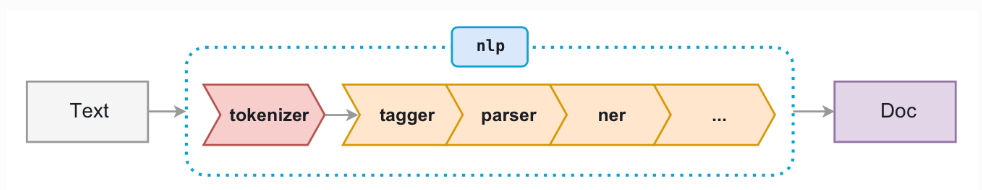

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
df = df.dropna(subset=["post"]).reset_index(drop=True)
# Keep negations - they matter for hate speech detection
nlp.vocab["not"].is_stop = False
nlp.vocab["no"].is_stop  = False

# Use first post as running example throughout
sample_text = df["post"].iloc[0]
doc = nlp(sample_text)

# tokenization
df["tokens"] = df["post"].apply(lambda x: [t.text for t in nlp(x)])

# Speech tagging
for token in doc:
    if not token.is_space:
        print(f"{token.text:<20} {token.pos_:<10} {token.tag_:<10} {spacy.explain(token.tag_)}")

# Apply to full dataframe
df["pos_tags"] = df["post"].apply(
    lambda x: [(t.text, t.pos_) for t in nlp(x) if not t.is_space]
)

# Entity recognition 
for ent in doc.ents:
    print(f"{ent.text:<30} {ent.label_:<15} {spacy.explain(ent.label_)}")

# Apply to full dataframe
df["entities"] = df["post"].apply(
    lambda x: [(ent.text, ent.label_) for ent in nlp(x).ents]
)

# tokenization
df["tokens_no_stop"] = df["post"].apply(
    lambda x: [
        t.text for t in nlp(x)
        if not t.is_stop and not t.is_punct and not t.is_space
    ]
)

# Lemmatization
df["lemmas"] = df["post"].apply(
    lambda x: [
        t.lemma_.lower() for t in nlp(x)
        if not t.is_stop and not t.is_punct and not t.is_space
    ]
)

# Chunking 
df["noun_chunks"] = df["post"].apply(
    lambda x: [chunk.text for chunk in nlp(x).noun_chunks]
)

# Dependency parsing
df["dep_parse"] = df["post"].apply(
    lambda x: [(t.text, t.dep_, t.head.text) for t in nlp(x) if not t.is_space]
)


In [ ]:
# Dependency parsing
all_lemmas  = [lemma for lemmas in df["lemmas"] for lemma in lemmas]
word_counts = Counter(all_lemmas)

print("Top 20 most frequent words across all SAP posts:")
freq_df = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])
display(freq_df)

df["word_count"] = df["tokens_no_stop"].apply(len)

In [ ]:
df.head()

In [ ]:
# Save preprocessed dataframe
df.to_csv("data/SAP_posts_preprocessed.csv", index=False)

# 2) Deep Learning Model

# 3) Evaluation of the Model